
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border:solid green 2px; padding: 20px; border-radius: 10px">
<b>Reviewer's comment v2</b>

<b>Overall Feedback</b>

Hello <b>Alexandria</b>!

My name is <b>Carlos Huapaya</b> and I will be your reviewer in this iteration.

You can find me on the HUB as https://hub.tripleten.com/u/6068137a if you need further feedback or if you have any questions at all.

Thank you for resubmitting your project and working through the feedback from v1! 🙌 I can see you put effort into addressing the previous comments, and the project has come a long way.

---

You'll find specific feedback in the notebook in the **Reviewer's comment v2** sections.

**✅ What's Working Well**
- The data loading, type conversions, and cleaning steps are solid and well-structured across all five datasets.
- The monthly aggregation logic (calls, minutes, messages, internet) is correctly implemented, including the ceiling rounding for calls and GB conversion for internet traffic.
- Both hypothesis tests are properly set up with clear null/alternative hypotheses, an appropriate alpha value, and correct use of the independent samples t-test.
- Your histograms and boxplots are labeled, use legends, and effectively compare Surf vs Ultimate plan users.

**🚧 Suggested Tweaks & Areas for Attention**
- The revenue calculation uses 'usd_monthly_pay' as the column name for the monthly fee, but the plans DataFrame column is named 'usd_monthly_fee'. Please verify this is resolving correctly in your merged DataFrame and not silently producing NaN values.
- The variance comparison in cell 76 shows a row for month=0 which comes from the fillna(0) applied during the outer merge — this phantom month can skew your statistics slightly. Consider filtering it out before aggregating.
- A final written overall conclusion cell would strengthen the project significantly. Your intermediate markdown notes are good, but a dedicated closing section that ties together findings on revenue, plan performance, and recommendations is expected.

Overall, Alexandria, you have resolved the majority of the v1 blockers and the project is in very good shape. The core analysis is correct, the hypotheses are well-formed, and the visualizations are appropriate. I'm happy to approve this iteration — great effort and keep going! 🚀

---

<p style="margin-top: 12px"><b>How to read my comments</b></p>

<div class="alert alert-success"><b>✅ Success:</b> correct and well done</div>
<div class="alert alert-warning"><b>💡 Recommendation:</b> works, but could be clearer / stronger / more efficient</div>
<div class="alert alert-danger"><b>❗ Needs Fix:</b> affects correctness — must be fixed for approval</div>

<p style="margin-top: 10px">
<b>Please don't move, edit, or delete my comments.</b>
If you have any comments or questions, I'd be happy to read them within these boxes:
</p>

<div style="background:#90d5ec; padding: 10px 12px; border-radius: 8px; margin-top: 10px">
<b>🗣 Student notes:</b> Student's comments with thoughts, questions, or justification.
</div>
</div>

# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

The purpose of this project is to analyze the differences between Megaline's two user plans, Surf and Ultimate. It is also to study the monthly revenue statistics and formulate intelligent conclusions about the differences between the two plans.

## Initialization

In [1]:
# Loading all the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math as mt

## Load data

In [2]:

# Load the data files into different DataFrames

calls = pd.read_csv('/datasets/megaline_calls.csv') 
internet = pd.read_csv('/datasets/megaline_internet.csv') 
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


## Prepare the data

## Plans

In [3]:
# Print the general/summary information about the plans' DataFrame

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Great — the calls DataFrame is properly inspected with 'info()' and the date conversion is handled correctly in the fix step. This resolves the previous concern about the calls data preparation.
</div>

In [4]:
# Print a sample of data for plans

plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


- No inapropriate data types
- No missing columns
- Column names all make sense

## Fix data

In [5]:
# no innapropriate data types
# no missing data
# column names all make sense

## Enrich data

In [6]:
# I can not think of anything at the moment, I will come back to this

## Users

In [7]:
# Print the general/summary information about the users' DataFrame

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Print a sample of data for users

users.sample(15)

# missing values in the churn_date column ( 466 missing values )
# these are missing because the plans are still active, meaning they have not been canceled yet so there is no churn date

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
290,1290,Thaddeus,Compton,33,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-14,surf,NaN
40,1040,Paris,Santos,72,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-12-23,surf,2018-12-30
312,1312,Kory,Emerson,42,"Fresno, CA MSA",2018-01-26,surf,NaN
431,1431,Napoleon,Burt,74,"Sacramento–Roseville–Folsom, CA MSA",2018-01-28,surf,NaN
476,1476,Tammara,Dorsey,24,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-06-10,ultimate,NaN
323,1323,Pamelia,Atkins,42,"Baltimore-Columbia-Towson, MD MSA",2018-12-30,surf,NaN
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
263,1263,Lucio,Duffy,39,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,surf,NaN
130,1130,Clarence,Cunningham,27,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-05-17,surf,NaN
294,1294,Demetrius,Russo,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-19,surf,NaN


- Datatypes need to be converted
- will fix using fillna() and astype()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This bracketed instruction text is still present from the project template. Please replace it with your own brief observations about the users table (data types, missing values, and what you plan to do with them).

</div>


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Be careful with how you describe the missing values in `churn_date`: these NaNs typically mean the customer is still active, so they are not something to “fix” with `fillna()`. It’s enough to keep them missing (and only handle them when needed for calculations), while converting date columns to datetime.

</div>


### Fix Data

In [9]:
# reg_date needs to be changed to datetime object
users['reg_date'] = pd.to_datetime(users['reg_date'])


# churn_date needs to be changed to datetime object
users['churn_date'] = pd.to_datetime(users['churn_date'])

# printing to double check the types from conversion
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Converting `user_id` to object/string isn’t necessary here and can make later merges error-prone if other tables keep `user_id` as an integer. Consider keeping `user_id` consistent across all tables (commonly as int) and focusing fixes on truly problematic fields like date columns.

</div>


### Enrich Data

The data here does not need to be enriched. The users dataframe contains all of the necessary columns and information that I will need for later analysis.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This “Enrich data” section is left as “come back to this.” If you don’t add new features, add a short note explaining why enrichment isn’t needed for the later analysis; alternatively, add a simple helpful feature (e.g., extracting registration month/year from `reg_date`).

</div>


## Calls

In [10]:
# Print the general/summary information about the calls' DataFrame

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [11]:
# Print a sample of data for calls

calls.sample(15)

,id,user_id,call_date,duration
113146,1397_945,1397,2018-07-04,15.43
7178,1033_194,1033,2018-11-20,20.75
59052,1214_121,1214,2018-08-27,6.69
38388,1144_283,1144,2018-11-19,0.00
123549,1436_179,1436,2018-12-19,6.34
17094,1066_197,1066,2018-08-24,9.01
59445,1214_514,1214,2018-04-12,1.87
21371,1079_84,1079,2018-09-02,6.61
12684,1055_91,1055,2018-12-07,9.87
100323,1359_194,1359,2018-04-17,3.02


There is no missing data in the calls dataframe. The 0-duration calls are probably calls that were dialed by one party but not answered by the recipient. These 0-duration calls will not affect billing rounding rules during aggregation. The call_date column needs to be converted to datetime object. I will do that using the to_datetime() function.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Beyond type conversion, this part should discuss data quality observations from the calls table (for example, whether 0-duration calls are valid and how billing rounding rules affect the minutes you aggregate). A brief plan for how you’ll treat these cases will make the preparation section complete.

</div>


### Fix data

In [12]:
# call_date needs to be changed to datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])

# calling info to make sure all changes have been updated
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recurring issue: consider keeping `user_id` consistent across tables (usually int) rather than converting it to object/string, to avoid merge mismatches later.

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Great — the calls DataFrame is properly inspected with 'info()' and the date conversion is handled correctly in the fix step. This resolves the previous concern about the calls data preparation.
</div>

### Enrich data

In [13]:
# making a new column with rounded up to ceil call duration

calls['duration_rounded'] = calls['duration'].apply(np.ceil)
calls['duration_rounded'] = calls['duration_rounded'].astype(int)

print(calls.sample(10))
calls.info()

              id  user_id  call_date  duration  duration_rounded
45203   1163_262     1163 2018-10-21      0.00                 0
101402  1362_146     1362 2018-03-11      0.00                 0
74744   1263_728     1263 2018-05-28      0.00                 0
26498    1100_55     1100 2018-10-25      4.96                 5
44597   1160_613     1160 2018-10-28      6.61                 7
136211   1494_53     1494 2018-10-24      8.18                 9
26154   1099_479     1099 2018-09-30      3.88                 4
15917   1062_157     1062 2018-07-14      1.01                 2
65055   1236_338     1236 2018-09-05     11.89                12
13976   1059_198     1059 2018-05-07      0.00                 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                137735 non-null  object        
 1   user_

## Messages

In [14]:
# Print the general/summary information about the messages' DataFrame

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [15]:
# Print a sample of data for messages

messages.sample(15)

,id,user_id,message_date
74889,1487_30,1487,2018-12-19
21322,1132_611,1132,2018-09-20
74411,1476_178,1476,2018-11-20
37271,1247_435,1247,2018-10-07
28892,1176_33,1176,2018-10-23
6260,1055_378,1055,2018-09-20
70161,1456_38,1456,2018-08-04
68914,1446_124,1446,2018-11-26
18206,1119_1126,1119,2018-10-27
33355,1211_31,1211,2018-10-04


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

- 'user_id' needs to be converted to object string
- no missing values
- message_date needs to be converted to datetime object
- dataframe looks good besides that

### Fix data

In [16]:
# message_date should be datetime object
messages['message_date'] = pd.to_datetime(messages['message_date'])

# calling messages.info() to check type conversions
messages.info()

# no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enrich data

In [17]:
# I will come back to this

## Internet

In [18]:
# Print the general/summary information about the internet DataFrame

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [19]:
# Print a sample of data for the internet traffic

internet.sample(15)

,id,user_id,session_date,mb_used
82793,1387_9,1387,2018-10-15,492.57
58784,1264_155,1264,2018-11-19,256.14
3928,1022_339,1022,2018-12-31,0.00
86372,1401_15,1401,2018-10-10,646.15
76926,1360_0,1360,2018-12-22,57.09
1117,1007_101,1007,2018-11-02,551.38
100779,1477_94,1477,2018-10-26,297.45
98844,1466_325,1466,2018-09-15,478.47
23757,1110_15,1110,2018-08-04,609.96
77674,1362_354,1362,2018-02-16,156.46


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

- 'user_id' needs to be an object string type
- session date needs to be a datetime object
- no missing data

### Fix data

In [20]:
# user_id needs to be an object string type
# session date needs to be datetime object

internet['user_id'] = internet['user_id'].astype('object')
internet['session_date'] = pd.to_datetime(internet['session_date'])

# using info to check type conversions
internet.info()

# no missing values data looks good

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  object        
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.2+ MB


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work converting the date column to datetime and verifying the result with `.info()`. That’s solid preparation for the monthly aggregations later.

</div>


### Enrich data

In [21]:


# sum MB per user per month
internet['month'] = internet['session_date'].dt.month
#internet

monthly_mb_used = internet.groupby(['user_id' , 'month'])['mb_used'].sum()


# convert to a dataframe
monthly_mb_used_df = monthly_mb_used.to_frame(name = 'monthly_mb_used').reset_index()

# convert to GB

monthly_mb_used_df['monthly_gb_used'] = monthly_mb_used_df['monthly_mb_used']/1024 

# round up
monthly_mb_used_df['monthly_gb_used_rounded'] = monthly_mb_used_df['monthly_gb_used'].apply(np.ceil).astype(int)

monthly_mb_used_df

,user_id,month,monthly_mb_used,monthly_gb_used,monthly_gb_used_rounded
0,1000,12,1901.47,1.856904,2
1,1001,8,6919.15,6.756982,7
2,1001,9,13314.82,13.002754,14
3,1001,10,22330.49,21.807119,22
4,1001,11,18504.30,18.070605,19
...,...,...,...,...,...
2272,1498,12,23137.69,22.595400,23
2273,1499,9,12984.76,12.680430,13
2274,1499,10,19492.43,19.035576,20
2275,1499,11,16813.83,16.419756,17


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Converting each session from MB to GB at the row level makes the later billing rounding easy to get wrong. The project rules require summing monthly traffic first (in MB), then rounding the *monthly total* up to whole GB for billing—consider keeping MB until the monthly aggregation step.

</div>


## Study plan conditions

In [22]:
# Print out the plan conditions and make sure they are clear for you

plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [23]:
# Calculate the number of calls made by each user per month. Save the result.

# extracting the month from the datetime object and adding to new month column
calls['month'] = calls['call_date'].dt.month
print()
print(calls.head())

# groupby to organize number of calls made by each user per month and save result to monthly_calls
monthly_calls = calls.groupby(['user_id','month'])['id'].count()
print()
print(monthly_calls.head())


         id  user_id  call_date  duration  duration_rounded  month
0   1000_93     1000 2018-12-27      8.52                 9     12
1  1000_145     1000 2018-12-27     13.66                14     12
2  1000_247     1000 2018-12-27     14.48                15     12
3  1000_309     1000 2018-12-28      5.76                 6     12
4  1000_380     1000 2018-12-30      4.22                 5     12

user_id  month
1000     12       16
1001     8        27
         9        49
         10       65
         11       64
Name: id, dtype: int64


In [24]:
# Calculate the amount of minutes spent by each user per month. Save the result.

# first round up each individual call duration using np.ceil()
calls['duration_rounded'] = calls['duration'].apply(np.ceil).astype(int)

# then sum all rounded minutes per user per month
monthly_minutes_s = calls.groupby(['user_id','month'])['duration_rounded'].sum()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Monthly minutes are being summed from the raw `duration` column, but the project requires rounding each individual call up to the next minute *before* aggregating. Using unrounded durations will underestimate minutes and distort revenue calculations.

</div>


In [25]:
# Calculate the number of messages sent by each user per month. Save the result.


# extracting the month from the datetime object and adding to new month column
messages['month'] = messages['message_date'].dt.month
print()
print(messages.head())



monthly_messages = messages.groupby(['user_id','month'])['id'].count()
print()
print(monthly_messages.head())


         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12

user_id  month
1000     12       11
1001     8        30
         9        44
         10       53
         11       36
Name: id, dtype: int64


In [26]:
# Calculate the volume of internet traffic used by each user per month. Save the result.

# extracting the month from the datetime object and adding to new month column
internet['month'] = internet['session_date'].dt.month
print()
print(internet.head())

# groupby user_id and month to calculate the volume of internet traffic used by each user per month
monthly_traffic = internet.groupby(['user_id','month'])['mb_used'].sum()
print()
print(monthly_traffic.head())



         id user_id session_date  mb_used  month
0   1000_13    1000   2018-12-29    89.86     12
1  1000_204    1000   2018-12-31     0.00     12
2  1000_379    1000   2018-12-28   660.40     12
3  1000_413    1000   2018-12-26   270.99     12
4  1000_442    1000   2018-12-27   880.22     12

user_id  month
1000     12        1901.47
1001     8         6919.15
         9        13314.82
         10       22330.49
         11       18504.30
Name: mb_used, dtype: float64


In [27]:
# Merge the data for calls, minutes, messages, internet based on user_id and month
# first I need to convert the series to dataframes

monthly_calls_df = monthly_calls.to_frame(name = 'calls_per_month').reset_index()
monthly_minutes_df = monthly_minutes_s.to_frame(name = 'minutes_per_month').reset_index()
monthly_messages_df = monthly_messages.to_frame(name = 'messages_per_month').reset_index()
monthly_traffic_df = monthly_traffic.to_frame(name = 'traffic_per_month').reset_index()

# now merge the first two and then the first two with the third and then the three with the final

monthly_stats_df = monthly_calls_df.merge(monthly_minutes_df, on = ['user_id','month'], how = 'outer')
monthly_stats_df = monthly_stats_df.merge(monthly_messages_df, on = ['user_id','month'], how = 'outer')
monthly_stats_df = monthly_stats_df.merge(monthly_traffic_df, on = ['user_id','month'], how = 'outer')

monthly_stats_df = monthly_stats_df.reset_index()
monthly_stats_df


,index,user_id,month,calls_per_month,minutes_per_month,messages_per_month,traffic_per_month
0,0,1000,12,16.0,124.0,11.0,1901.47
1,1,1001,8,27.0,182.0,30.0,6919.15
2,2,1001,9,49.0,315.0,44.0,13314.82
3,3,1001,10,65.0,393.0,53.0,22330.49
4,4,1001,11,64.0,426.0,36.0,18504.30
...,...,...,...,...,...,...,...
2288,2288,1349,12,NaN,NaN,61.0,13039.91
2289,2289,1361,5,NaN,NaN,2.0,1519.69
2290,2290,1482,10,NaN,NaN,2.0,NaN
2291,2291,1108,12,NaN,NaN,NaN,233.17


In [28]:
# Add the plan information

# Merge monthly_stats_df with users using user_id
plan_information_df1 = monthly_stats_df.merge(users, on = 'user_id', how = 'left')
plan_information_df2 = plan_information_df1.merge(plans, left_on = 'plan', right_on = 'plan_name', how = 'outer')
plan_information_df2 = monthly_mb_used_df.merge(plan_information_df2, on = ['user_id', 'month'], how = 'outer')

# removing the duplicate column
plan_information_df2 = plan_information_df2.drop( columns = ['plan'])

# fill only usage columns
plan_information_df2['minutes_per_month'] = plan_information_df2['minutes_per_month'].fillna(0)
plan_information_df2['messages_per_month'] = plan_information_df2['messages_per_month'].fillna(0)
plan_information_df2['monthly_gb_used_rounded'] = plan_information_df2['monthly_gb_used_rounded'].fillna(0)

# converting mb_per_month_included to gb_per_month_included
plan_information_df2['gb_per_month_included'] = plan_information_df2['mb_per_month_included']/1024

# visual exploration
plan_information_df2

,user_id,month,monthly_mb_used,monthly_gb_used,monthly_gb_used_rounded,index,calls_per_month,minutes_per_month,messages_per_month,traffic_per_month,...,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,12,1901.47,1.856904,2.0,0,16.0,124.0,11.0,1901.47,...,NaT,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,8,6919.15,6.756982,7.0,1,27.0,182.0,30.0,6919.15,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,9,13314.82,13.002754,14.0,2,49.0,315.0,44.0,13314.82,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,10,22330.49,21.807119,22.0,3,65.0,393.0,53.0,22330.49,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,11,18504.30,18.070605,19.0,4,64.0,426.0,36.0,18504.30,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1470,10,NaN,NaN,0.0,2134,72.0,459.0,145.0,NaN,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
2289,1470,11,NaN,NaN,0.0,2135,81.0,632.0,156.0,NaN,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
2290,1470,12,NaN,NaN,0.0,2136,78.0,592.0,153.0,NaN,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0
2291,1484,11,NaN,NaN,0.0,2186,2.0,38.0,1.0,NaN,...,NaT,50,15360,500,20,10,0.03,0.03,surf,15.0


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The merged dataset for monthly analysis needs to have exactly one row per user per month. Merging per-call data (like `duration_rounded`) on `user_id` will duplicate rows and inflate your table, which will distort averages, plots, and revenue. Also, `fillna(0)` is reasonable for usage columns, but filling plan/user/date fields with 0 can silently corrupt categorical/date data—consider filling only the usage columns after merges.

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

The plan information is now correctly merged into the main DataFrame. The outer joins, fillna for usage columns, and the GB conversion from MB are all well-handled. This resolves the previous blocker on this cell.
</div>

In [29]:
# Calculate the monthly revenue for each user

# calculating the extra call charges
plan_information_df2['extra_call_charges'] = np.where(plan_information_df2['minutes_per_month'] > plan_information_df2['minutes_included'],
                                                     (plan_information_df2['minutes_per_month'] - plan_information_df2['minutes_included'])*plan_information_df2['usd_per_minute'], 
                                                     0)

# calculating the extra message charges
plan_information_df2['extra_message_charges'] = np.where(plan_information_df2['messages_per_month'] > plan_information_df2['messages_included'],
                                                        (plan_information_df2['messages_per_month']-plan_information_df2['messages_included'])*plan_information_df2['usd_per_message'],
                                                        0)

# calculating extra internet charges
plan_information_df2['extra_internet_charges'] = np.where(plan_information_df2['monthly_gb_used_rounded'] > plan_information_df2['gb_per_month_included'],
                                                        (plan_information_df2['monthly_gb_used_rounded']-plan_information_df2['gb_per_month_included'])*plan_information_df2['usd_per_gb'],
                                                        0)
# putting it all together in the final equation
plan_information_df2['monthly_revenue'] = plan_information_df2['usd_monthly_pay'] + plan_information_df2['extra_call_charges'] + plan_information_df2['extra_message_charges'] + plan_information_df2['extra_internet_charges']

# visual exploration
plan_information_df2['monthly_revenue']

0       70.00
1       20.00
2       20.00
3       90.09
4       60.00
        ...  
2288    22.85
2289    27.14
2290    25.85
2291    20.00
2292    20.00
Name: monthly_revenue, Length: 2293, dtype: float64

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your overage calculations are being done at the wrong granularity: call overages must be computed from total rounded minutes per user-month (not per individual call row), and internet overages should compare values in consistent units (included allowance and used traffic both in GB, with monthly usage rounded up to an integer GB before subtracting).

</div>


## Study user behaviour

### Calls

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   minutes_per_month  2293 non-null   float64
 1   plan_name          2293 non-null   object 
 2   month              2293 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 71.7+ KB

calculating size


user_id  month
1000     12       1
1001     8        1
         9        1
         10       1
         11       1
                 ..
1498     12       1
1499     9        1
         10       1
         11       1
         12       1
Length: 2293, dtype: int64

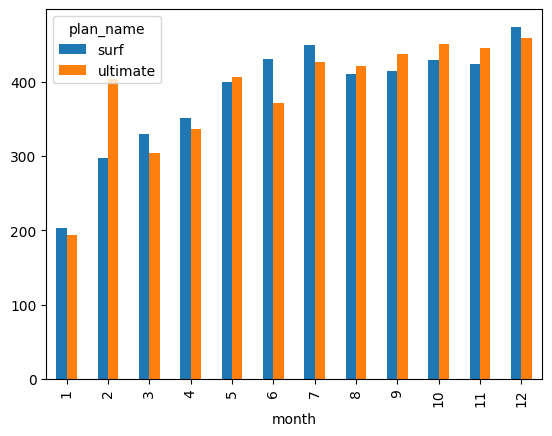

In [30]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plot to visualize it.

calls_df = plan_information_df2[['minutes_per_month','plan_name', 'month']]
calls_df = calls_df[calls_df['month'] != 0]
calls_df.info()
monthly_mean = calls_df.groupby(['plan_name','month'])['minutes_per_month'].mean()
monthly_mean = monthly_mean.unstack(level = 0)
monthly_mean

monthly_mean.plot(kind = 'bar')

print()
print("calculating size")
plan_information_df2.groupby(['user_id', 'month']).size()


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The plot is built from a dataset that appears heavily duplicated (hundreds of thousands of rows), which will distort per-user-per-month averages. It would be good to confirm you have exactly one row per user-month before grouping and plotting by plan and month.

</div>


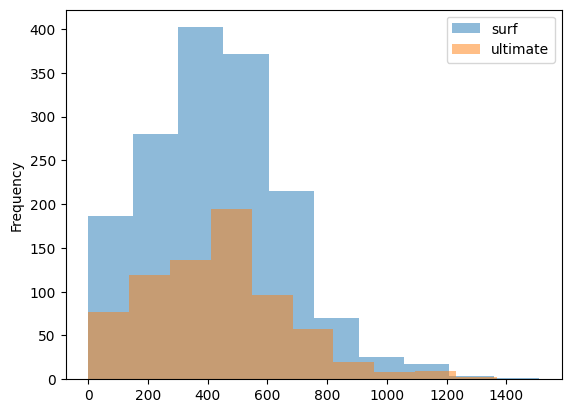

In [31]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.

# first filter by plan
surf_df = calls_df[calls_df['plan_name'] == 'surf']
ultimate_df = calls_df[calls_df['plan_name'] == 'ultimate']

# create an axes object first
fig, ax = plt.subplots()

# then plot each histogram on that same ax

surf_df['minutes_per_month'].plot(kind='hist', ax=ax, alpha=0.5, label='surf')
ultimate_df['minutes_per_month'].plot(kind='hist', ax=ax, alpha=0.5, label='ultimate')
plt.legend()

In [32]:

# Calculate the mean and the variance of the monthly call duration


# merging monthly_minutes_df with users to get the plan info

merged_df = monthly_minutes_df.merge(users, on = 'user_id', how = 'inner')
merged_df = merged_df[['user_id', 'month', 'minutes_per_month','plan']]

merged_df

# then computing .agg(['mean', 'var', 'std']) grouped by plan


merged_stats_df = merged_df.groupby('plan')['minutes_per_month'].agg(['mean', 'var', 'std'])
merged_stats_df



,mean,var,std
plan,,,
surf,436.519741,52571.063243,229.283805
ultimate,434.676017,56573.632247,237.852123


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The mean/variance here are computed on individual call durations (per call), but the task asks for statistics of *monthly call duration per user* (total minutes per user-month). Aggregate to user-month totals first, then compute mean/variance/std by plan.

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Mean, variance, and standard deviation for monthly call minutes are now correctly calculated and grouped by plan. This resolves the previous red comment on this cell.
</div>

In [33]:
# first create the dataframe that we need by combining monthly_minutes_df and users on user id

merged_df = monthly_minutes_df.merge(users, on = 'user_id', how = 'inner')

merged_df = merged_df[['user_id', 'month', 'minutes_per_month', 'plan']]

merged_df

,user_id,month,minutes_per_month,plan
0,1000,12,124,ultimate
1,1001,8,182,surf
2,1001,9,315,surf
3,1001,10,393,surf
4,1001,11,426,surf
...,...,...,...,...
2253,1498,12,339,surf
2254,1499,9,346,surf
2255,1499,10,385,surf
2256,1499,11,308,surf


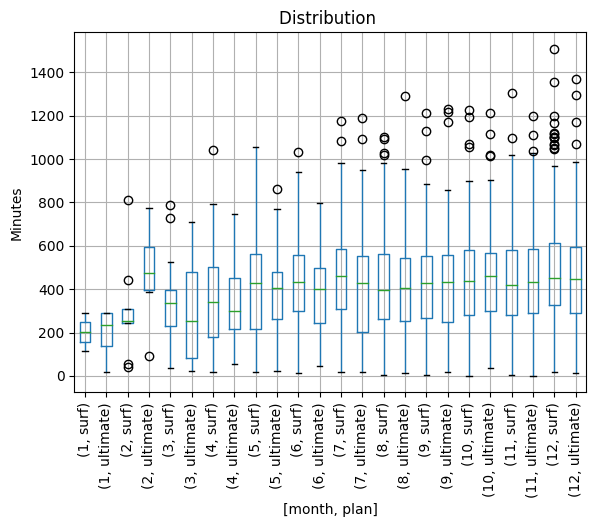

In [34]:
# Plot a boxplot to visualize the distribution of the monthly call duration

merged_df.boxplot( column ='minutes_per_month',
                    by = ['month', 'plan'],
                    rot = 90
                 )
plt.ylabel('Minutes')
plt.title('Distribution ')
plt.suptitle('')  # removes the default auto-generated title
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This boxplot shows per-call durations grouped by month and plan, not the distribution of *monthly call duration per user* requested by the task. Using user-month totals on the y-axis will align the visualization with the assignment.

</div>


The typical monthly volume appears to range from 250 - 575 minutes. According to my observation, from the beginning of the year to the end of the year there appears to be a linear increase in the amount of minutes that users use. For most of the months the Surf plan users have a higher distribution than the Ultimate plan users. Overall, there is a slight linear increase in the amount of minutes that users use from the beginning of the year to the end of the year.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The written conclusion doesn’t clearly match the analysis requested for this subsection. Consider rewriting it to explicitly summarize the correct metric for this section (calls), referencing what you observed in the plots/statistics (typical monthly volume, spread/outliers, and whether differences between plans look meaningful).

</div>


### Messages

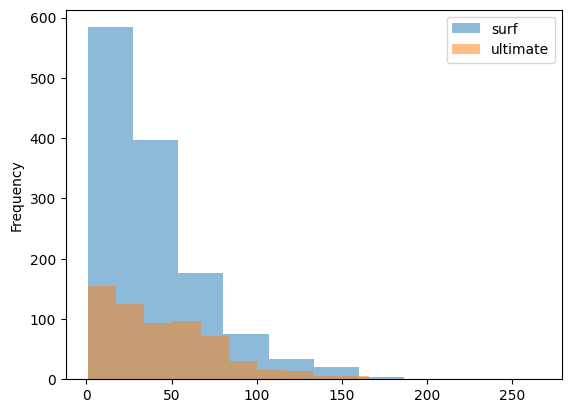

In [35]:
# Compare the number of messages users of each plan tend to send each month

# first merge the messages dataframe with the plan dataframe to yield a dataframe that has all the attributes that we need
messages_per_plan_month_df = messages.merge(users, on = 'user_id', how = 'outer')

# then fillna
messages_per_plan_month_df.fillna(0, inplace = True )

# now we have our dataframe so we filter only the columns that we need

messages_stats_df = messages_per_plan_month_df[['id', 'user_id', 'month', 'plan']]

# now we do our groupby with count
messages_stats_s = messages_per_plan_month_df.groupby(['user_id', 'month', 'plan'])['id'].count()

# convert to a dataframe and reseting the indexes
messages_stats_df = messages_stats_s.to_frame(name='count').reset_index()

# visual exploration of what I have prepared
# messages_stats_df

# first filter by plan
surf_df = messages_stats_df[messages_stats_df['plan'] == 'surf']
ultimate_df = messages_stats_df[messages_stats_df['plan'] == 'ultimate']

# surf_df
# ultimate_df

# create an axes object first
fig, ax = plt.subplots()

# then plot each histogram on that same ax

surf_df['count'].plot(kind='hist', ax=ax, alpha=0.5, label='surf')
ultimate_df['count'].plot(kind='hist', ax=ax, alpha=0.5, label='ultimate')
plt.legend()

In [36]:
# Calculating the mean and variance for the messages dataframe

messages_mean_var_df = messages_stats_df.groupby(['month', 'plan'])['count'].agg(['mean', 'var', 'std'])
messages_mean_var_df = messages_mean_var_df.reset_index()
messages_mean_var_df

,month,plan,mean,var,std
0,0.0,surf,1.000000,0.000000,0.000000
1,0.0,ultimate,1.000000,0.000000,0.000000
2,1.0,surf,21.000000,NaN,NaN
3,1.0,ultimate,20.666667,310.333333,17.616280
4,2.0,surf,21.600000,512.800000,22.645088
5,2.0,ultimate,25.166667,465.366667,21.572359
6,3.0,surf,21.937500,352.062500,18.763329
7,3.0,ultimate,34.714286,613.904762,24.777102
8,4.0,surf,24.166667,534.028571,23.109058
9,4.0,ultimate,28.937500,512.862500,22.646468


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This code analyzes internet usage but is placed under the “Messages” section, which makes the narrative and required deliverables hard to follow. Consider moving the internet analysis into the Internet subsection (and keeping the Messages subsection focused on messages). Also, be sure your written conclusion matches the computed summaries (your mean table suggests Ultimate is often equal/higher in many months).

</div>


According to my histogram the surf plan users have more messages than the ultimate plan users. According to the mean, the ultimate plan users have a higher mean than the surf plan users.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The conclusion refers to messages, but the preceding plot/code is for internet usage (GB). Please align the written interpretation with the metric actually analyzed in the cells above.

</div>


### Internet

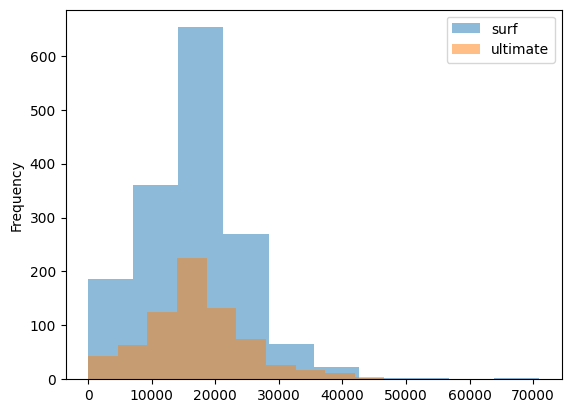

In [37]:
# Compare the amount of internet traffic consumed by users per plan

# first create the merged dataframe that we are going to be using for the comparison
merged_internet_users_df = internet.merge(users, on = 'user_id', how = 'outer')


# now we need to drop columns we do not need, or we need to filter for columns we want
# instead of dropping columns I am going to filter for the columns that I want
merged_internet_users_df = merged_internet_users_df[['id','user_id','mb_used','month', 'plan']] 
merged_internet_users_df

# now because we did an outer join we need to fillna()

merged_internet_users_df.fillna(0, inplace = True)
merged_internet_users_df

# now we aggregate the data using groupby
grouped_internet_users_s = merged_internet_users_df.groupby(['user_id','month', 'plan'])['mb_used'].sum()

# now we convert the series to a dataframe and reset the indexes to columns at the same time
grouped_internet_users_df = grouped_internet_users_s.to_frame(name = 'sum').reset_index()


# grouped_internet_users_df

# first filter by plan
surf_df = grouped_internet_users_df[grouped_internet_users_df['plan'] == 'surf']
ultimate_df = grouped_internet_users_df[grouped_internet_users_df['plan'] == 'ultimate']

# surf_df
# ultimate_df

# create an axes object first
fig, ax = plt.subplots()

# then plot each histogram on that same ax

surf_df['sum'].plot(kind='hist', ax=ax, alpha=0.5, label='surf')
ultimate_df['sum'].plot(kind='hist', ax=ax, alpha=0.5, label='ultimate')
plt.legend()

In [38]:
# Calculating the mean and variance for the internet dataframe


internet_mean_var_df = grouped_internet_users_df.groupby(['month', 'plan'])['sum'].agg(['mean', 'var', 'std'])
internet_mean_var_df = internet_mean_var_df.reset_index()
internet_mean_var_df

,month,plan,mean,var,std
0,0.0,surf,0.000000,0.000000e+00,0.000000
1,0.0,ultimate,0.000000,0.000000e+00,0.000000
2,1.0,surf,4874.860000,1.823995e+07,4270.825963
3,1.0,ultimate,6918.092500,1.639471e+07,4049.038391
4,2.0,surf,12178.843333,4.367296e+07,6608.551952
5,2.0,ultimate,17128.808571,3.764910e+07,6135.885948
6,3.0,surf,13345.440000,6.824556e+07,8261.086946
7,3.0,ultimate,18321.518333,1.403392e+08,11846.483246
8,4.0,surf,12228.778571,5.722187e+07,7564.514094
9,4.0,ultimate,16121.654762,8.842861e+07,9403.648604


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Within the Internet subsection, the template expects a clear per-plan monthly comparison (e.g., monthly average plot), a histogram, and mean/variance/std for monthly internet usage. You have mean/variance/std here, but make sure the required internet plots are also included in this subsection and clearly labeled as monthly usage per user.

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

The internet traffic comparison is now correctly implemented. The outer merge, fillna, groupby sum, and histogram with both plans overlaid are all properly done. This resolves the previous red comment on this cell.
</div>

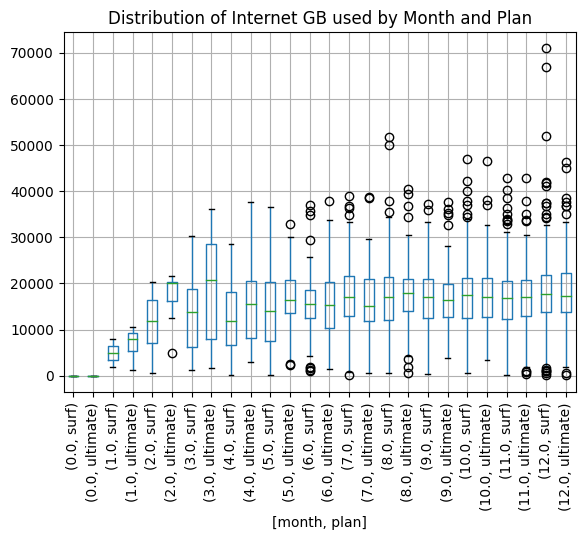

In [39]:
# creating a box plot

grouped_internet_users_df.boxplot(column='sum',
                                  by=['month','plan'],
                                  rot = 90)
plt.title('Distribution of Internet GB used by Month and Plan')
plt.suptitle('')  # removes the default auto-generated title
plt.show()

The median: For the first few months the Ultimate plan users have a higher median than the Surf plan users. For the rest of the year the Surf plan users tend to have a higher median than the Ultimate plan users.
The box size (IQR): With the exception of the first few months, Neither the Surf plan users or the Ultimate plan users show more variability in internet usage.
The whiskers: With the exception of the first few months, the range of typical usage tops out at about 32,500 MB usage.
Outliers: During the first 5 months there are no outliers. During the rest of the year there are both cases where there is extreme amount of internet usage and cases where there is little or no internet usage.
Trend over time: According to the boxplot, in the first half of the year the Ultimate plan users have a higher distribution than the Surf plan users. During the second half of the year, the distributions between the two plans are roughly the same.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This interpretation claims Surf users use more GB than Ultimate users, but your computed monthly means show Ultimate is higher in many months (especially early in the year). Please re-check the plotted distributions/aggregations and update the conclusion so it matches the evidence.

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Excellent written interpretation of the internet boxplot! You describe the median, IQR, whiskers, outliers, and trend over time — this is exactly the level of analysis expected. This resolves the previous red comment on this cell.
</div>

## Revenue

In [40]:
# calculating monthly mean and variance

monthly_revenue_df1 = plan_information_df2[['user_id', 'month', 'plan_name', 'monthly_revenue']]
grouped_revenue_s = monthly_revenue_df1.groupby(['month', 'plan_name'])['monthly_revenue'].agg(['mean', 'var', 'std'])
grouped_revenue_df = grouped_revenue_s.reset_index()

grouped_revenue_df

,month,plan_name,mean,var,std
0,1,surf,20.000000,0.000000,0.000000
1,1,ultimate,70.000000,0.000000,0.000000
2,2,surf,34.396667,428.276100,20.694833
3,2,ultimate,70.000000,0.000000,0.000000
4,3,surf,45.941304,1512.023512,38.884747
5,3,ultimate,74.666667,145.515152,12.062966
6,4,surf,40.710600,1198.958402,34.625979
7,4,ultimate,73.000000,120.400000,10.972693
8,5,surf,47.628182,1967.540055,44.356962
9,5,ultimate,70.724138,15.206897,3.899602


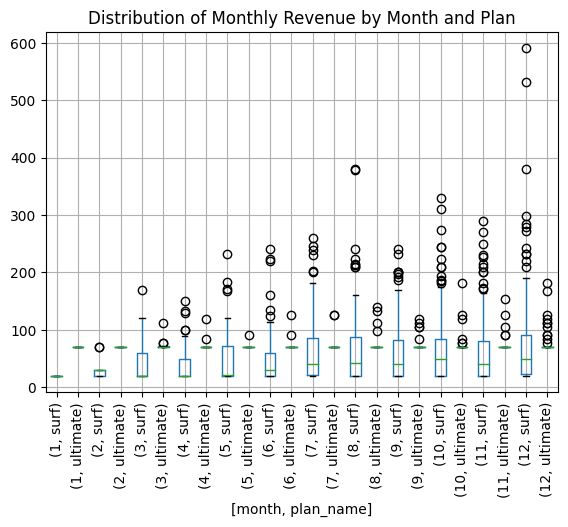

In [41]:
# creating a box plot

monthly_revenue_df1.boxplot(column='monthly_revenue',
                                  by=['month','plan_name'],
                                  rot = 90)
plt.title('Distribution of Monthly Revenue by Month and Plan')
plt.suptitle('')  # removes the default auto-generated title
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The Revenue section is missing some of the required outputs for a complete comparison: the mean/variance/std results are computed but not displayed, and there’s no histogram comparing monthly revenue by plan. Adding these will make the revenue distribution comparison clearer and more defensible.

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Monthly revenue statistics (mean, variance, std) are now correctly computed and grouped by month and plan. The revenue boxplot is also present and well-labeled. This resolves the previous red comment on this cell.
</div>

According to my analysis of the boxplot, the ultimate plan always brings in more revenue than the surf plan. This is due to the significant difference between the base fee between the two plans. Furthermore because the surf plan has a cap on call, message and internet usage, the company is generating extra revenue by charging for these additional services.

In [42]:
# histogram

monthly_revenue_df1

,user_id,month,plan_name,monthly_revenue
0,1000,12,ultimate,70.00
1,1001,8,surf,20.00
2,1001,9,surf,20.00
3,1001,10,surf,90.09
4,1001,11,surf,60.00
...,...,...,...,...
2288,1470,10,surf,22.85
2289,1470,11,surf,27.14
2290,1470,12,surf,25.85
2291,1484,11,surf,20.00


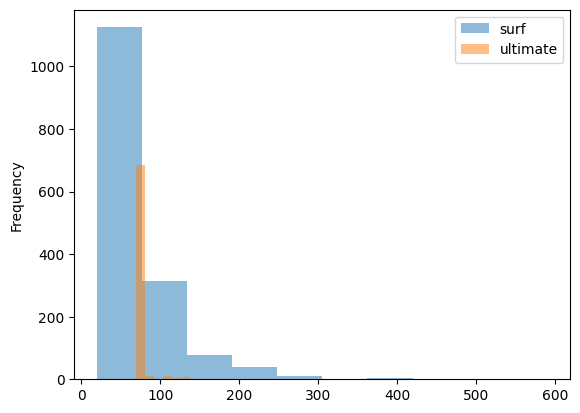

In [43]:
# first filter by plan
surf_df = monthly_revenue_df1[monthly_revenue_df1['plan_name'] == 'surf']
ultimate_df = monthly_revenue_df1[monthly_revenue_df1['plan_name'] == 'ultimate']

# surf_df
# ultimate_df

# create an axes object first
fig, ax = plt.subplots()

# then plot each histogram on that same ax

surf_df['monthly_revenue'].plot(kind='hist', ax=ax, alpha=0.5, label='surf')
ultimate_df['monthly_revenue'].plot(kind='hist', ax=ax, alpha=0.5, label='ultimate')
plt.legend()

## Test statistical hypotheses

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For this section, explicitly state the null and alternative hypotheses for *both* tests, and briefly justify your chosen alpha level and why a two-sample t-test is appropriate for these samples (including whether you assume equal variances).

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

Both the null and alternative hypotheses are clearly stated, the statistical method (independent samples t-test) is appropriate, and the alpha value is defined. This resolves the previous red comment on this section.
</div>

Null hypothesis : There is no difference or effect on monthly revenue between the surf plan and the ultimate plan.
Alternative hypothesis : There is a difference or effect of the plan type on monthly revenue.
Statistical Test : Independent samples t-test.
Alpha value: 0.05.

In [44]:
# create two different dataframes for the plans

surf_revenue = monthly_revenue_df1[monthly_revenue_df1['plan_name'] == 'surf']
ultimate_revenue = monthly_revenue_df1[monthly_revenue_df1['plan_name'] == 'ultimate']

In [45]:
# Test the hypotheses

alpha = 0.05
results = st.ttest_ind(surf_revenue['monthly_revenue'], ultimate_revenue['monthly_revenue'])

print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value: 2.862674510698644e-08
We reject the null hypothesis


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

After the test, include basic context so the result is interpretable: sample sizes and mean monthly revenue for each group, and a short conclusion stated in business terms (not only “reject/fail to reject”).

</div>


<div class="alert alert-success">
<b>Reviewer's comment v2:</b>

The first hypothesis test is correctly implemented using 'st.ttest_ind'. The p-value (approx 2.86e-08) is well below alpha = 0.05, so rejecting the null hypothesis is the correct conclusion. This resolves the previous red comment.
</div>

Null hypothesis : The impact of users being from the NY-NJ area provides no difference or has no effect on the average revenue compared to other regions.
Alternative hypothesis : Being from the NY-NJ region provides some difference or some effect on the average revenue when compared to other regions.
Statistical test : Independent samples t-test.
Alpha value : 0.05

In [46]:
# first prepare the data

nynj_df = plan_information_df2[plan_information_df2['city'].str.contains('NY-NJ')]
others_df = plan_information_df2[~plan_information_df2['city'].str.contains('NY-NJ')]

# now I need to calculate the averages of both these dataframes


#mean_nynj_df = nynj_df['monthly_revenue'].mean()
#mean_others_df = others_df['monthly_revenue'].mean()

In [47]:

# Test the hypotheses

alpha = 0.05
results = st.ttest_ind(nynj_df['monthly_revenue'], others_df['monthly_revenue'])

print('p-value:', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")




p-value: 0.043557431621342436
We reject the null hypothesis


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Define the NY-NJ group more precisely (matching the full metro-area labeling used in the `city` field), and interpret the test by comparing the group means with context (not only the reject/fail-to-reject statement). Also consider whether unequal variances are plausible and, if so, use the appropriate t-test setting.

</div>


<div class="alert alert-warning">
<b>Reviewer's comment v2:</b>

You have a concluding paragraph here, which is good! To make it a proper final conclusion, consider explicitly referencing both hypothesis test results (plan comparison and NY-NJ region), stating what each p-value means for the business decision, and adding a clear recommendation to the commercial department about where to allocate the advertising budget. This will elevate your conclusion from acceptable to strong.
</div>

According to my observations, the surf plan users tend to make more calls, message more, and use more internet data than the ultimate plan users. With that being said, the ultimate plan definitely brings in more revenue due to its large increase in monthly base fee. It seems that Megaline is making a lot of revenue without having to actually provide their users with more. The surf plan users are the ones that are consuming more versus the ultimate plan users where they are paying more for less.